# Testing notebook

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import sys
import os

# Add the src directory to the Python path
src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
sys.path.append(src_path)
print(f"Added to path: {src_path}")

# Import from your modules
from create_timeseries import construct_time_series
from vec_storage import TimeSeriesVectorStore
from data_input import load_data_csv, load_data_json, load_data_excel
from data_cleaning import clean_data

# Define process_dataset function since it's not in create_timeseries
def process_dataset(file_path, dataset_name=None):
    """
    Load, clean, and convert a dataset to time series format
    """
    # Load data based on file type
    if file_path.endswith('.csv'):
        df, _ = load_data_csv(file_path)
    elif file_path.endswith('.json'):
        df, _ = load_data_json(file_path)
    elif file_path.endswith(('.xlsx', '.xls')):
        df, _ = load_data_excel(file_path)
    else:
        raise ValueError(f"Unsupported file format: {file_path}")
    
    # Clean data
    clean_df = clean_data(df, file_path, dataset_name)
    
    # Create time series
    ts = construct_time_series(clean_df)
    
    return ts, clean_df

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
%matplotlib inline

In [ ]:
# Define your datasets
datasets = [
    {"path": "../data/raw/avocado_full.csv", "name": "avocado_sales"},
    {"path": "../data/raw/donut_searches.json", "name": "donut_searches"},
]

# Process all datasets
time_series_data = {}
raw_data = {}

for dataset in datasets:
    print(f"Processing {dataset['name']}...")
    ts, df = process_dataset(dataset['path'], dataset['name'])
    time_series_data[dataset['name']] = ts
    raw_data[dataset['name']] = df
    print(f"  Time series length: {len(ts)}")

print("\nAll datasets processed successfully!")

In [ ]:
# First, let's recreate dataset_vectors with multiple windows from each time series
dataset_vectors = {}

for name, ts in time_series_data.items():
    # Instead of using the entire time series as one embedding,
    # let's create multiple embeddings using sliding windows
    window_size = 30
    stride = 10  # Smaller stride = more overlapping windows = more embeddings
    
    # Create sliding windows
    windows = []
    for i in range(0, len(ts) - window_size + 1, stride):
        window = ts.values[i:i+window_size]
        windows.append(window)
    
    dataset_vectors[name] = windows

print(f"Created {sum(len(windows) for windows in dataset_vectors.values())} windows total")
for name, windows in dataset_vectors.items():
    print(f"Dataset '{name}' has {len(windows)} windows")

# Now add these multiple windows to the vector store
window_size = 30
fft_components = 20

# Calculate the correct dimension
dimension = TimeSeriesVectorStore.calculate_embedding_dimension(window_size, fft_components)
print(f"Correct dimension: {dimension}")

# Create vector store with the correct dimension
vector_store = TimeSeriesVectorStore(dimension=dimension)

# Add all datasets to vector store
for source, windows in dataset_vectors.items():
    # Convert windows to numpy arrays
    time_series_list = [np.array(window) for window in windows]
    
    # Add to vector store
    vector_store.add_time_series(
        time_series_list, 
        window_size=window_size, 
        stride=1,  # Stride is 1 since we already created the windows
        fft_components=fft_components,
        source=source
    )

print(f"Vector store created with {vector_store.index.ntotal} embeddings")
print(f"Sources in vector store: {list(vector_store.sources)}")

# Let's check how many embeddings we have per source
for source in vector_store.sources:
    vectors, metadata, indices = vector_store.get_vectors_by_source(source)
    print(f"Source '{source}' has {len(vectors)} embeddings")

In [ ]:
# Define dataset pairs to compare
source_pairs = [
    ("avocado_sales", "donut_searches"),
]

# Perform cross-dataset analysis
cross_similarities = {}
for source1, source2 in source_pairs:
    print(f"Comparing {source1} and {source2}...")
    similarities = vector_store.cross_dataset_similarity(source1, source2, top_k=5)
    cross_similarities[f"{source1}_{source2}"] = similarities

print("\nCross-dataset analysis completed!")

=== CROSS-DATASET SIMILARITY HEATMAP ===
Cross-similarity matrix shape: (7, 115)


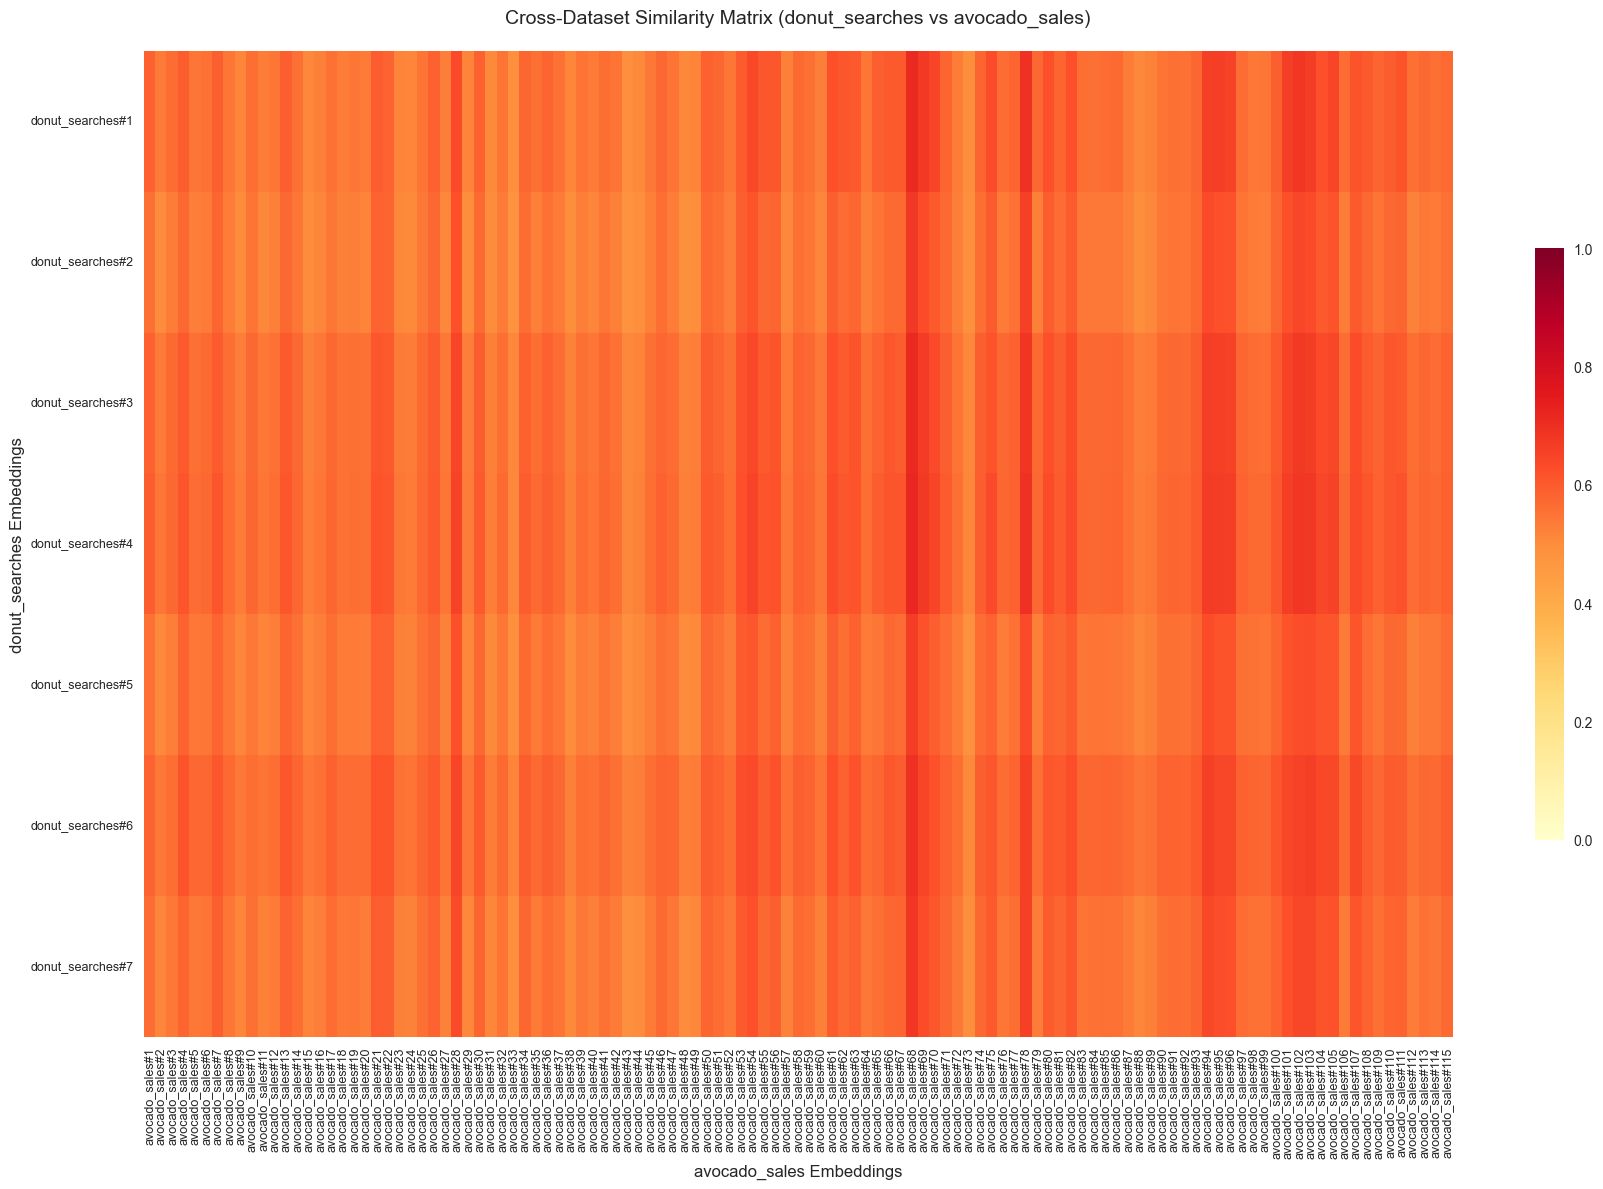

In [23]:
# === CROSS-DATASET SIMILARITY HEATMAP ===

print("=== CROSS-DATASET SIMILARITY HEATMAP ===")

# Collect unique sources
unique_sources = list(set(all_sources))
if len(unique_sources) != 2:
    raise ValueError(f"Expected exactly 2 datasets, but found {len(unique_sources)}: {unique_sources}")

src_a, src_b = unique_sources

# Separate embeddings by dataset
dataset_a_vectors = [vec for vec, src in zip(all_vectors, all_sources) if src == src_a]
dataset_b_vectors = [vec for vec, src in zip(all_vectors, all_sources) if src == src_b]

dataset_a_labels = [f"{src_a}#{i+1}" for i in range(len(dataset_a_vectors))]
dataset_b_labels = [f"{src_b}#{i+1}" for i in range(len(dataset_b_vectors))]

dataset_a_vectors = np.array(dataset_a_vectors)
dataset_b_vectors = np.array(dataset_b_vectors)

# Compute cross-similarity matrix (A vs B only)
cross_similarity_matrix = cosine_similarity(dataset_a_vectors, dataset_b_vectors)
print(f"Cross-similarity matrix shape: {cross_similarity_matrix.shape}")

# Plot stretched heatmap
plt.figure(figsize=(18, 12))  # wider & taller than before
sns.heatmap(
    cross_similarity_matrix,
    cmap="YlOrRd",
    vmin=0, vmax=1,
    xticklabels=dataset_b_labels,
    yticklabels=dataset_a_labels,
    cbar_kws={"shrink": 0.6},
    square=False  # allow non-square cells
)

plt.xlabel(f"{src_b} Embeddings", fontsize=12)
plt.ylabel(f"{src_a} Embeddings", fontsize=12)
plt.title(f"Cross-Dataset Similarity Matrix ({src_a} vs {src_b})", fontsize=14, pad=20)

# Rotate labels for readability
plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()
